# Human Activity Recognition with a Hidden Markov Model
**Formative 2 - Hidden Markov Models**

This notebook implements the full pipeline:
1. Load motion recordings (Sensor Logger CSVs) and **harmonize sampling rates**
2. **Window** the signals and extract **time-domain + frequency-domain features**
3. Train a **Gaussian HMM from scratch** with **Baum-Welch** (log-likelihood convergence check)
4. Decode activities with **Viterbi**
5. Evaluate on **unseen recordings**: sensitivity, specificity, accuracy, confusion matrix
6. Visualize **transition** and **emission** probabilities

> **Before running:** put your recordings in `data/train/` and `data/test/` following the
> naming convention in the README (`<activity>_<member>_<nn>.csv`, e.g. `walking_alice_03.csv`).
> Test files must be *new recordings never used for training*.

In [1]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.optimize import linear_sum_assignment

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

# ---------------- configuration ----------------
DATA_TRAIN = 'data/train'
DATA_TEST  = 'data/test'

ACTIVITIES = ['still', 'standing', 'walking', 'jumping']   # hidden states
TARGET_FS  = 50          # Hz - common sampling rate all phones are resampled to
WINDOW_SEC = 1.0         # window length in seconds
OVERLAP    = 0.5         # 50% overlap between consecutive windows

WINDOW = int(TARGET_FS * WINDOW_SEC)   # samples per window
STEP   = int(WINDOW * (1 - OVERLAP))   # hop size
print(f'Window = {WINDOW} samples ({WINDOW_SEC}s at {TARGET_FS} Hz), hop = {STEP} samples')

Window = 50 samples (1.0s at 50 Hz), hop = 25 samples


## 1. Data loading and sampling-rate harmonization

**Why harmonize?** Different phones sample at different, often irregular, rates (e.g. one member's
phone at ~100 Hz, another at ~50 Hz). Features like FFT bins and window sizes are only comparable
if every recording lives on the same time grid, so we **linearly interpolate every recording onto a
uniform grid at `TARGET_FS` Hz**.

**Windowing logic (explain this in your report):** we use **1-second windows with 50% overlap**.
At 50 Hz that is 50 samples per window - long enough to contain at least one full cycle of the
slowest periodic activity (walking ~ 1.5-2.5 Hz, i.e. one step every 0.4-0.7 s) so the FFT can
resolve its dominant frequency, but short enough that a window almost never straddles two
activities. The 50% overlap doubles the number of observations without changing the model.

The loader supports two layouts:
- **Flat CSV**: one file per recording with a time column + 6 signal columns (`ax,ay,az,gx,gy,gz`)
- **Sensor Logger folder**: a folder per recording containing `Accelerometer.csv` and `Gyroscope.csv`
  (merged on nearest timestamp)

The **activity label is parsed from the file/folder name prefix** (e.g. `walking_alice_03`).

In [2]:
TIME_CANDIDATES = ['seconds_elapsed', 'time', 'timestamp', 'Time (s)', 'elapsed']

def _find_time_col(df):
    for c in TIME_CANDIDATES:
        if c in df.columns:
            return c
    # fall back: first numeric monotonically-increasing column
    for c in df.columns:
        v = pd.to_numeric(df[c], errors='coerce')
        if v.notna().all() and v.is_monotonic_increasing:
            return c
    raise ValueError(f'No time column found in columns: {list(df.columns)}')

def _to_seconds(t):
    t = pd.to_numeric(t, errors='coerce').to_numpy(dtype=float)
    t = t - t[0]
    if t[-1] > 1e6:      # nanoseconds
        t = t / 1e9
    elif t[-1] > 1e4:    # milliseconds
        t = t / 1e3
    return t

def _load_sensorlogger_folder(folder):
    acc = pd.read_csv(os.path.join(folder, 'Accelerometer.csv'))
    gyr = pd.read_csv(os.path.join(folder, 'Gyroscope.csv'))
    ta, tg = _to_seconds(acc[_find_time_col(acc)]), _to_seconds(gyr[_find_time_col(gyr)])
    A = acc[['x', 'y', 'z']].to_numpy(float)
    G = gyr[['x', 'y', 'z']].to_numpy(float)
    # interpolate gyro onto accelerometer timeline
    Gi = np.column_stack([np.interp(ta, tg, G[:, i]) for i in range(3)])
    return ta, np.hstack([A, Gi])

def _load_flat_csv(path):
    df = pd.read_csv(path)
    t = _to_seconds(df[_find_time_col(df)])
    cols = [c for c in df.columns if re.search(r'(acc|gyr|^a[xyz]$|^g[xyz]$|_x$|_y$|_z$|^x$|^y$|^z$)',
                                               c, re.I) and c not in TIME_CANDIDATES]
    sig = df[cols].apply(pd.to_numeric, errors='coerce').to_numpy(float)
    if sig.shape[1] < 3:
        raise ValueError(f'{path}: found only {sig.shape[1]} signal columns ({cols})')
    return t, sig

def estimate_fs(t):
    dt = np.diff(t)
    return 1.0 / np.median(dt[dt > 0])

def resample(t, sig, fs=TARGET_FS):
    tt = np.arange(t[0], t[-1], 1.0 / fs)
    return np.column_stack([np.interp(tt, t, sig[:, i]) for i in range(sig.shape[1])])

def label_from_name(name):
    base = os.path.basename(name).lower()
    for a in ACTIVITIES:
        if base.startswith(a):
            return a
    raise ValueError(f'Cannot parse activity from "{name}" - name files <activity>_<member>_<nn>')

def load_dataset(root):
    records = []   # (label, member/file, native_fs, resampled signal)
    entries = sorted(glob.glob(os.path.join(root, '*')))
    if not entries:
        raise FileNotFoundError(f'No recordings found in "{root}" - add your CSVs first.')
    for e in entries:
        try:
            if os.path.isdir(e):
                t, sig = _load_sensorlogger_folder(e)
            elif e.lower().endswith(('.csv', '.txt')):
                t, sig = _load_flat_csv(e)
            else:
                continue
            fs = estimate_fs(t)
            records.append(dict(name=os.path.basename(e), label=label_from_name(e),
                                native_fs=fs, sig=resample(t, sig)))
        except Exception as ex:
            print(f'  ! skipped {e}: {ex}')
    return records

train_recs = load_dataset(DATA_TRAIN)
test_recs  = load_dataset(DATA_TEST)

summary = pd.DataFrame([{'file': r['name'], 'activity': r['label'],
                         'native_fs_Hz': round(r['native_fs'], 1),
                         'duration_s': round(len(r['sig']) / TARGET_FS, 1)}
                        for r in train_recs])
print(f'{len(train_recs)} training / {len(test_recs)} test recordings')
print('\nNative sampling rate per file (put the per-member rates in your report):')
display(summary)
display(summary.groupby('activity')['duration_s'].agg(['count', 'sum']))

32 training / 8 test recordings

Native sampling rate per file (put the per-member rates in your report):


,file,activity,native_fs_Hz,duration_s
0,jumping_01,jumping,99.3,8.7
1,jumping_02,jumping,99.3,8.9
2,jumping_03,jumping,99.3,7.9
3,jumping_04,jumping,99.3,9.1
4,jumping_05,jumping,99.3,9.3
5,jumping_06,jumping,99.3,8.8
6,jumping_07,jumping,99.3,8.8
7,jumping_08,jumping,99.3,10.0
8,standing_01,standing,99.3,8.9
9,standing_02,standing,99.3,9.8


,count,sum
activity,,
jumping,8,71.5
standing,8,73.0
still,8,71.5
walking,8,75.3


### Raw-data visualization
One example recording per activity - these plots go in the *Data Collection* section of the report.

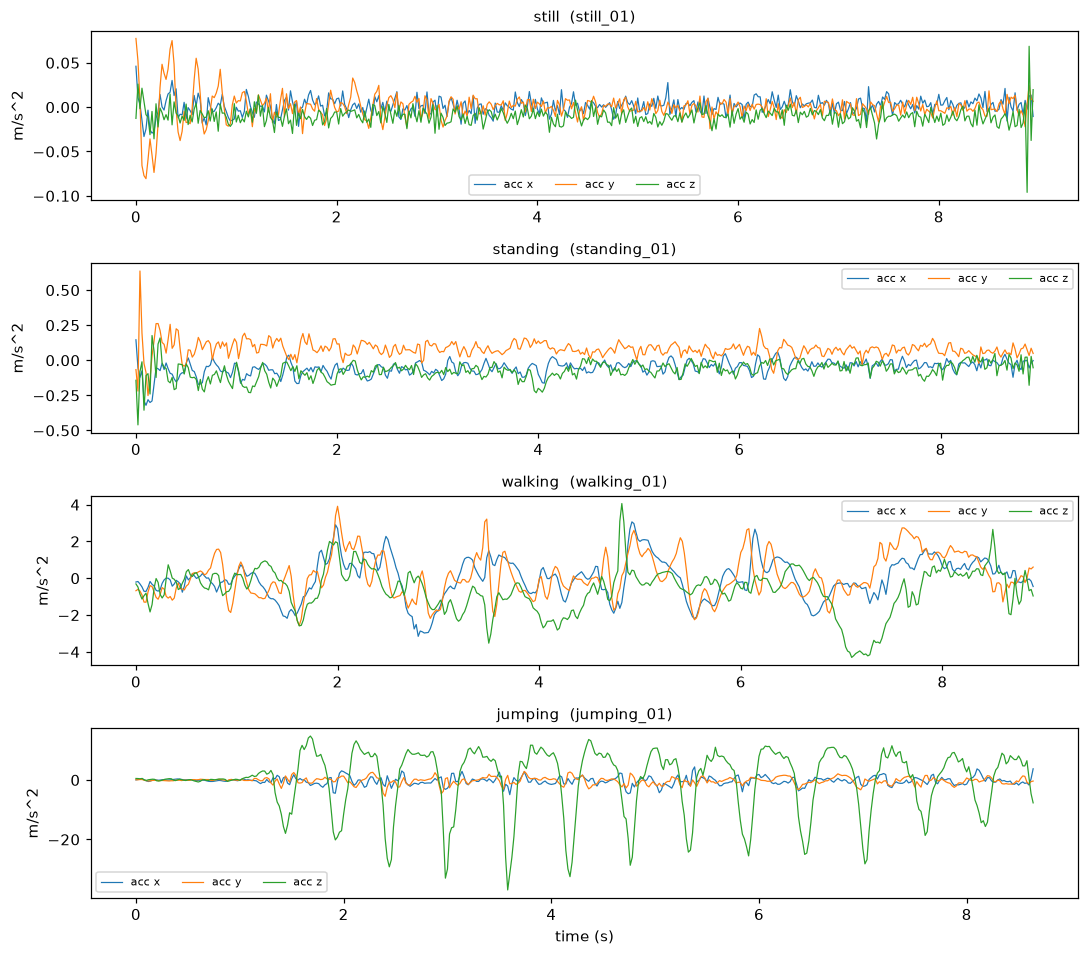

In [3]:
fig, axes = plt.subplots(len(ACTIVITIES), 1, figsize=(10, 2.2 * len(ACTIVITIES)), sharex=False)
for ax, act in zip(np.atleast_1d(axes), ACTIVITIES):
    rec = next((r for r in train_recs if r['label'] == act), None)
    if rec is None:
        ax.set_title(f'{act} - NO DATA'); continue
    t = np.arange(len(rec['sig'])) / TARGET_FS
    for i, lab in enumerate(['acc x', 'acc y', 'acc z']):
        ax.plot(t, rec['sig'][:, i], lw=0.8, label=lab)
    ax.set_title(f'{act}  ({rec["name"]})', fontsize=10)
    ax.set_ylabel('m/s^2'); ax.legend(fontsize=7, ncol=3)
axes[-1].set_xlabel('time (s)')
plt.tight_layout(); plt.show()

## 2. Feature extraction (time + frequency domain)

Per window of each axis-group we compute, and **why each helps** (personalize this in the report):

| Feature | Domain | Why it discriminates activities |
|---|---|---|
| Mean (acc z) | time | Phone orientation / gravity component differs between standing, still, walking |
| Standard deviation | time | Still ~ 0, standing small (body sway), walking medium, jumping large |
| RMS of magnitude | time | Overall motion intensity, orientation-independent |
| Signal Magnitude Area (SMA) | time | Classic HAR intensity feature, robust to axis orientation |
| Axis correlation (x-z) | time | Walking couples horizontal & vertical motion periodically |
| Dominant frequency (FFT) | frequency | Walking ~ 1.5-2.5 Hz, jumping ~ 2-4 Hz, static ~ 0 Hz |
| Spectral energy (FFT) | frequency | Total power in 0.5-10 Hz band separates dynamic vs static |

All features are **z-score normalized** using **training-set statistics only** (mean/std computed on
train, applied to test) - this keeps every feature on a comparable scale for the Gaussian emissions
and avoids information leaking from the test set.

In [ ]:
FEATURE_NAMES = ['mean_az', 'std_mag', 'rms_mag', 'SMA', 'corr_xz',
                 'dom_freq', 'spec_energy']

def window_features(w, fs=TARGET_FS):
    '''w: (WINDOW, >=6) resampled samples -> 1 feature vector.'''
    acc = w[:, :3]
    mag = np.linalg.norm(acc, axis=1)
    magc = mag - mag.mean()                       # remove gravity offset for spectra

    # time domain
    mean_az = acc[:, 2].mean()
    std_mag = mag.std()
    rms_mag = np.sqrt((magc ** 2).mean())
    sma = np.abs(acc).sum() / len(w)
    sx, sz = acc[:, 0].std(), acc[:, 2].std()
    corr_xz = (np.corrcoef(acc[:, 0], acc[:, 2])[0, 1]
               if sx > 1e-6 and sz > 1e-6 else 0.0)

    # frequency domain (FFT of gravity-removed magnitude)
    spec = np.abs(np.fft.rfft(magc * np.hanning(len(magc)))) ** 2
    freqs = np.fft.rfftfreq(len(magc), d=1.0 / fs)
    band = (freqs >= 0.5) & (freqs <= 10)         # human-motion band
    dom_freq = freqs[band][spec[band].argmax()] if band.any() and spec[band].max() > 0 else 0.0
    spec_energy = spec[band].sum() / len(magc)

    return np.array([mean_az, std_mag, rms_mag, sma, corr_xz, dom_freq, spec_energy])

def extract_sequence(sig):
    '''One recording -> (n_windows, n_features) observation sequence.'''
    F = [window_features(sig[s:s + WINDOW])
         for s in range(0, len(sig) - WINDOW + 1, STEP)]
    return np.array(F)

def build(records):
    seqs, labels, names = [], [], []
    for r in records:
        F = extract_sequence(r['sig'])
        if len(F) == 0:
            print(f'  ! {r["name"]} shorter than one window - skipped'); continue
        seqs.append(F); labels.append(r['label']); names.append(r['name'])
    return seqs, labels, names

train_seqs, train_labels, train_names = build(train_recs)
test_seqs,  test_labels,  test_names  = build(test_recs)

# z-score normalization: statistics from TRAINING data only
all_train = np.vstack(train_seqs)
mu_f, sd_f = all_train.mean(0), all_train.std(0) + 1e-9
train_seqs = [(s - mu_f) / sd_f for s in train_seqs]
test_seqs  = [(s - mu_f) / sd_f for s in test_seqs]

print(f'{len(train_seqs)} training sequences, {sum(len(s) for s in train_seqs)} windows, '
      f'{len(FEATURE_NAMES)} features')
pd.DataFrame(all_train, columns=FEATURE_NAMES).describe().round(2)

32 training sequences, 533 windows, 7 features


,mean_az,std_mag,rms_mag,SMA,corr_xz,dom_freq,spec_energy
count,533.00,533.00,533.00,533.00,533.00,533.00,533.00
mean,-0.09,1.79,1.79,3.81,0.14,3.89,103.67
std,1.01,2.87,2.87,5.51,0.33,2.68,213.07
min,-3.58,0.00,0.00,0.02,-0.80,1.00,0.00
25%,-0.15,0.02,0.02,0.10,-0.09,2.00,0.00
50%,-0.01,0.21,0.21,1.16,0.12,3.00,0.26
75%,0.02,1.12,1.12,3.65,0.38,5.00,10.68
max,3.65,9.84,9.84,16.67,0.92,10.00,1176.24


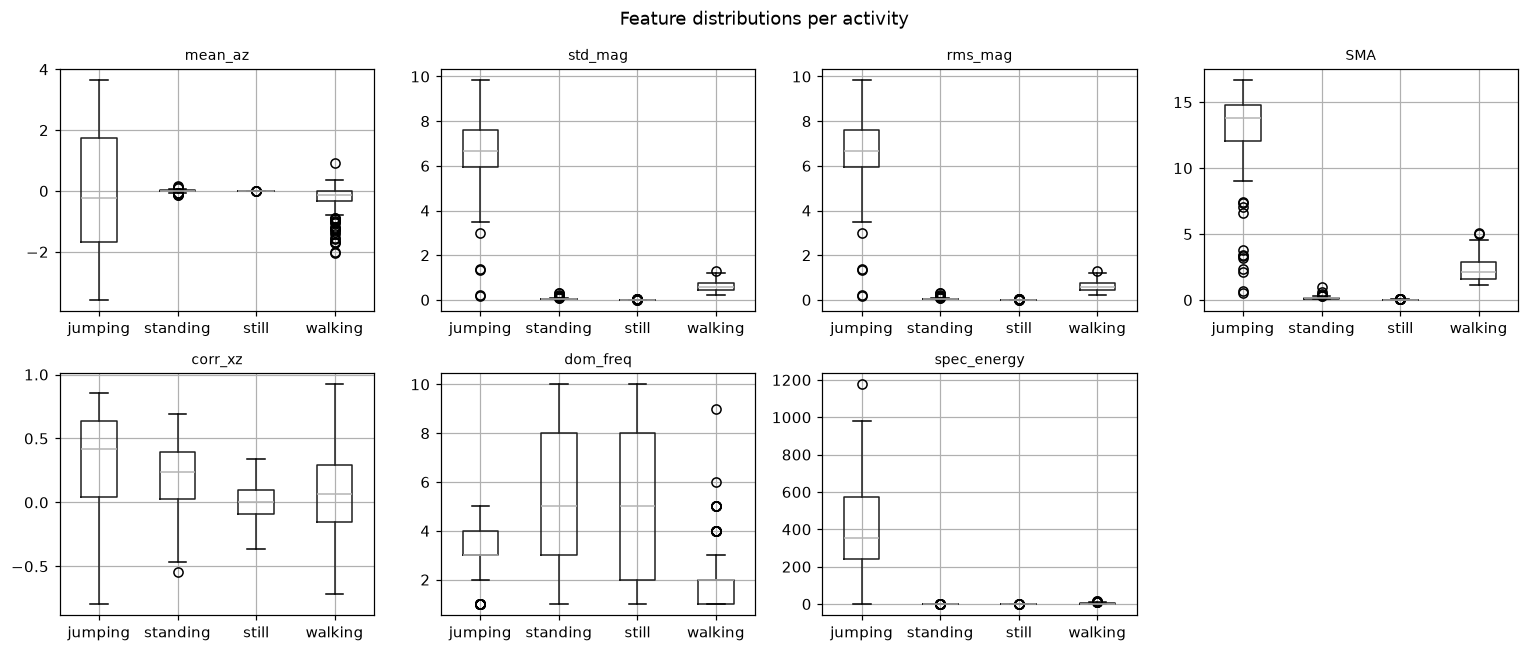

In [5]:
# Feature separability check - box plots per activity (report-worthy figure)
dfF = pd.DataFrame(np.vstack([np.vstack(
        [extract_sequence(r['sig']) for r in train_recs if r['label'] == a])
        for a in ACTIVITIES]), columns=FEATURE_NAMES)
dfF['activity'] = np.concatenate(
        [[a] * sum(len(extract_sequence(r['sig'])) for r in train_recs if r['label'] == a)
         for a in ACTIVITIES])
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, f in zip(axes.ravel(), FEATURE_NAMES):
    dfF.boxplot(column=f, by='activity', ax=ax)
    ax.set_title(f, fontsize=9); ax.set_xlabel('')
axes.ravel()[-1].axis('off')
plt.suptitle('Feature distributions per activity'); plt.tight_layout(); plt.show()

## 3. HMM definition

| Element | In this project |
|---|---|
| Hidden states $Z$ | the 4 activities: still, standing, walking, jumping |
| Observations $X$ | the 7-dimensional z-scored feature vector per 1-s window |
| Transitions $A$ | $P(z_t = j \mid z_{t-1} = i)$ - learned by Baum-Welch |
| Emissions $B$ | diagonal-covariance Gaussian per state: $x_t \mid z_t \sim \mathcal N(\mu_z, \sigma_z^2)$ |
| Initial $\pi$ | $P(z_1)$ - learned by Baum-Welch |

## 4. From-scratch implementation (Viterbi + Baum-Welch)

Everything is computed in **log-space** with `logsumexp` for numerical stability.
Baum-Welch stops when **|delta-LL| < epsilon** (a real convergence criterion), with `max_iter`
only as a safety cap.

In [ ]:
"""Gaussian HMM (diagonal covariance) implemented from scratch with numpy.
- Log-space forward/backward (numerically stable)
- Viterbi decoding
- Baum-Welch (EM) training with log-likelihood convergence check
"""
class GaussianHMM:
    def __init__(self, n_states, n_features, seed=42):
        self.N = n_states
        self.D = n_features
        rng = np.random.default_rng(seed)
        self.log_pi = np.log(np.full(n_states, 1.0 / n_states))
        A = rng.dirichlet(np.ones(n_states) * 5.0, size=n_states)
        self.log_A = np.log(A)
        self.means = rng.normal(0, 0.5, size=(n_states, n_features))
        self.vars = np.ones((n_states, n_features))

    # emissions
    def _log_emission(self, X):
        """log B: shape (T, N). Diagonal-covariance Gaussian log-pdf."""
        X = np.atleast_2d(X)
        diff = X[:, None, :] - self.means[None, :, :]          # (T, N, D)
        log_p = -0.5 * (np.log(2 * np.pi * self.vars)[None] +
                        diff ** 2 / self.vars[None])
        return log_p.sum(axis=2)                                # (T, N)

    # forward / backward
    def _forward(self, log_B):
        T = log_B.shape[0]
        log_alpha = np.zeros((T, self.N))
        log_alpha[0] = self.log_pi + log_B[0]
        for t in range(1, T):
            log_alpha[t] = log_B[t] + logsumexp(
                log_alpha[t - 1][:, None] + self.log_A, axis=0)
        return log_alpha

    def _backward(self, log_B):
        T = log_B.shape[0]
        log_beta = np.zeros((T, self.N))
        for t in range(T - 2, -1, -1):
            log_beta[t] = logsumexp(
                self.log_A + (log_B[t + 1] + log_beta[t + 1])[None, :], axis=1)
        return log_beta

    def log_likelihood(self, X):
        log_B = self._log_emission(X)
        return logsumexp(self._forward(log_B)[-1])

    # Viterbi
    def viterbi(self, X):
        """Most likely hidden state path for observation sequence X (T, D)."""
        log_B = self._log_emission(X)
        T = log_B.shape[0]
        delta = np.zeros((T, self.N))
        psi = np.zeros((T, self.N), dtype=int)
        delta[0] = self.log_pi + log_B[0]
        for t in range(1, T):
            scores = delta[t - 1][:, None] + self.log_A       # (N, N)
            psi[t] = scores.argmax(axis=0)
            delta[t] = scores.max(axis=0) + log_B[t]
        path = np.zeros(T, dtype=int)
        path[-1] = delta[-1].argmax()
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path, delta[-1].max()

    # Baum-Welch
    def fit(self, sequences, max_iter=200, tol=1e-4, min_var=1e-3, verbose=True):
        """
        EM training on a list of observation sequences.
        Stops when |LL_new - LL_old| < tol (proper convergence check),
        with max_iter as a safety cap only.
        """
        history = []
        prev_ll = -np.inf
        for it in range(max_iter):
            total_ll = 0.0
            # accumulators
            pi_acc = np.zeros(self.N)
            xi_acc = np.zeros((self.N, self.N))
            gamma_acc = np.zeros(self.N)
            mean_acc = np.zeros((self.N, self.D))
            var_acc = np.zeros((self.N, self.D))

            gammas = []
            for X in sequences:
                log_B = self._log_emission(X)
                log_alpha = self._forward(log_B)
                log_beta = self._backward(log_B)
                ll = logsumexp(log_alpha[-1])
                total_ll += ll

                log_gamma = log_alpha + log_beta - ll
                gamma = np.exp(log_gamma)                      # (T, N)
                gammas.append(gamma)

                T = X.shape[0]
                if T > 1:
                    # xi: (T-1, N, N)
                    log_xi = (log_alpha[:-1, :, None] + self.log_A[None] +
                              (log_B[1:] + log_beta[1:])[:, None, :] - ll)
                    xi_acc += np.exp(logsumexp(log_xi, axis=0))

                pi_acc += gamma[0]
                gamma_acc += gamma.sum(axis=0)
                mean_acc += gamma.T @ X

            # ----- M-step -----
            self.log_pi = np.log(pi_acc / pi_acc.sum() + 1e-300)
            A = xi_acc / (xi_acc.sum(axis=1, keepdims=True) + 1e-300)
            self.log_A = np.log(A + 1e-300)
            new_means = mean_acc / (gamma_acc[:, None] + 1e-300)

            for X, gamma in zip(sequences, gammas):
                diff = X[:, None, :] - new_means[None, :, :]
                var_acc += np.einsum('tn,tnd->nd', gamma, diff ** 2)
            self.means = new_means
            self.vars = np.maximum(var_acc / (gamma_acc[:, None] + 1e-300),
                                   min_var)

            history.append(total_ll)
            delta_ll = total_ll - prev_ll
            if verbose and (it % 10 == 0 or abs(delta_ll) < tol):
                print(f"  iter {it:3d}  log-likelihood = {total_ll:.3f}  "
                      f"delta = {delta_ll:.6f}")
            if abs(delta_ll) < tol:
                if verbose:
                    print(f"  Converged at iteration {it} "
                          f"(|delta LL| = {abs(delta_ll):.2e} < tol = {tol})")
                break
            prev_ll = total_ll
        return history

## 5. Training

We initialize the emission means with **per-activity training averages** (a light supervised warm
start - standard practice; Baum-Welch then refines everything unsupervised). This makes state  to 
activity correspondence stable and convergence fast. We also keep the label-free mapping step later,
so the pipeline still works with a fully random init.

  iter   0  log-likelihood = -182.730  delta = inf


  iter  10  log-likelihood = 1866.843  delta = 0.003913


  iter  12  log-likelihood = 1866.843  delta = 0.000063
  Converged at iteration 12 (|delta LL| = 6.34e-05 < tol = 0.0001)


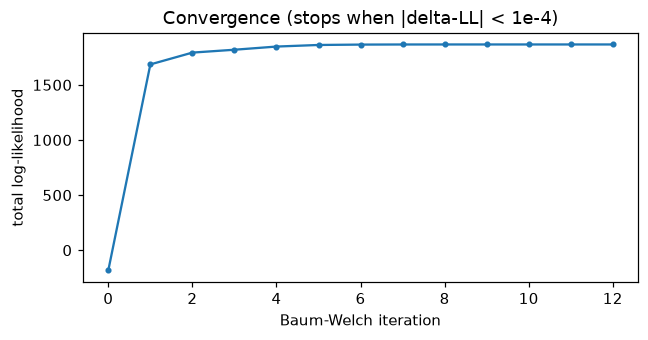

In [7]:
N_STATES = len(ACTIVITIES)
hmm = GaussianHMM(N_STATES, len(FEATURE_NAMES), seed=42)

# warm-start emission means from labelled training windows
for k, act in enumerate(ACTIVITIES):
    W = np.vstack([s for s, l in zip(train_seqs, train_labels) if l == act])
    hmm.means[k] = W.mean(0)
    hmm.vars[k]  = np.maximum(W.var(0), 1e-2)

history = hmm.fit(train_seqs, max_iter=200, tol=1e-4)

plt.figure(figsize=(6, 3.2))
plt.plot(history, marker='o', ms=3)
plt.xlabel('Baum-Welch iteration'); plt.ylabel('total log-likelihood')
plt.title('Convergence (stops when |delta-LL| < 1e-4)'); plt.tight_layout(); plt.show()

### Transition & emission probability visualizations

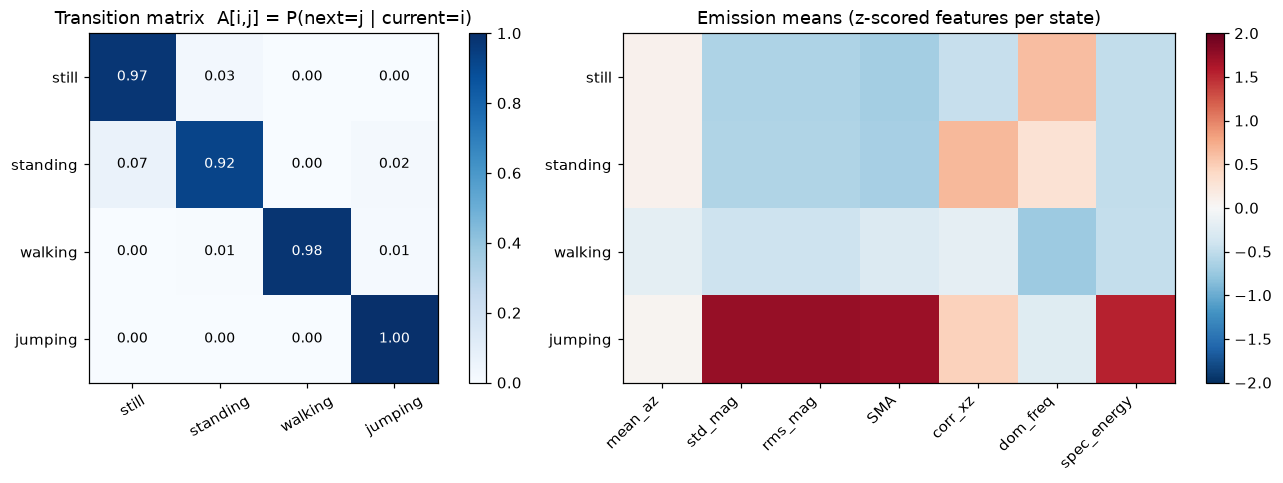

pi = [0.34  0.167 0.337 0.156]


In [8]:
A = np.exp(hmm.log_A)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

im0 = axes[0].imshow(A, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(N_STATES), ACTIVITIES, rotation=30)
axes[0].set_yticks(range(N_STATES), ACTIVITIES)
axes[0].set_title('Transition matrix  A[i,j] = P(next=j | current=i)')
for i in range(N_STATES):
    for j in range(N_STATES):
        axes[0].text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                     color='white' if A[i,j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(hmm.means, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
axes[1].set_xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(N_STATES), ACTIVITIES)
axes[1].set_title('Emission means (z-scored features per state)')
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout(); plt.show()

print('pi =', np.round(np.exp(hmm.log_pi), 3))

## 6. Evaluation on unseen data (Viterbi decoding)

The state to activity mapping is recovered **from the training data only** (Hungarian assignment on
the training confusion counts), then frozen and applied to the unseen test recordings.

In the report, describe **how the unseen data was obtained** (new session on a different day /
different participant / different environment) and reflect on generalization.

state to activity mapping: {0: 'still', 1: 'standing', 2: 'walking', 3: 'jumping'}


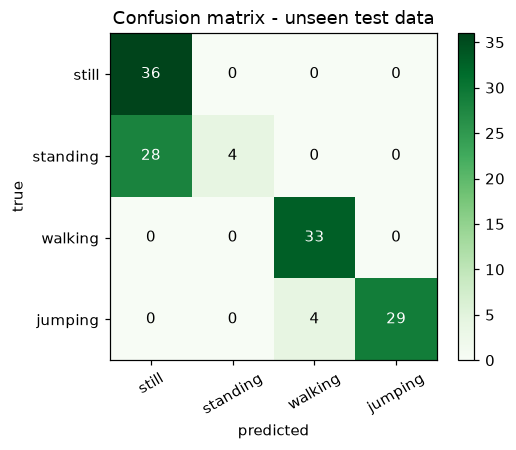

In [9]:
def decode_all(seqs):
    return [hmm.viterbi(s)[0] for s in seqs]

lab2idx = {a: i for i, a in enumerate(ACTIVITIES)}

# --- recover state->activity mapping on TRAINING data ---
train_paths = decode_all(train_seqs)
Cmap = np.zeros((N_STATES, N_STATES))
for path, lab in zip(train_paths, train_labels):
    for s in path:
        Cmap[lab2idx[lab], s] += 1
rows, cols = linear_sum_assignment(-Cmap)
state2act = {int(s): int(a) for a, s in zip(rows, cols)}
print('state to activity mapping:',
      {s: ACTIVITIES[a] for s, a in state2act.items()})

# --- decode unseen test data ---
test_paths = decode_all(test_seqs)
y_true = np.concatenate([[lab2idx[l]] * len(p) for l, p in zip(test_labels, test_paths)])
y_pred = np.concatenate([[state2act[s] for s in p] for p in test_paths])

# --- confusion matrix ---
CM = np.zeros((N_STATES, N_STATES), dtype=int)
for t, p in zip(y_true, y_pred):
    CM[t, p] += 1

plt.figure(figsize=(5, 4.2))
plt.imshow(CM, cmap='Greens')
plt.xticks(range(N_STATES), ACTIVITIES, rotation=30); plt.yticks(range(N_STATES), ACTIVITIES)
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Confusion matrix - unseen test data')
for i in range(N_STATES):
    for j in range(N_STATES):
        plt.text(j, i, CM[i, j], ha='center', va='center',
                 color='white' if CM[i, j] > CM.max()/2 else 'black')
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()

In [10]:
# --- per-activity sensitivity / specificity / accuracy (report table) ---
rows = []
total = CM.sum()
for i, act in enumerate(ACTIVITIES):
    TP = CM[i, i]
    FN = CM[i].sum() - TP
    FP = CM[:, i].sum() - TP
    TN = total - TP - FN - FP
    rows.append({'State (Activity)': act,
                 'Number of Samples': int(CM[i].sum()),
                 'Sensitivity': round(TP / (TP + FN + 1e-12), 3),
                 'Specificity': round(TN / (TN + FP + 1e-12), 3),
                 'Overall Accuracy': round((TP + TN) / total, 3)})
metrics = pd.DataFrame(rows)
display(metrics)
print(f'Global accuracy on unseen data: {(y_true == y_pred).mean():.3f}')

,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,still,36,1.000,0.714,0.791
1,standing,32,0.125,1.000,0.791
2,walking,33,1.000,0.960,0.970
3,jumping,33,0.879,1.000,0.970


Global accuracy on unseen data: 0.761


### Decoded sequence plots

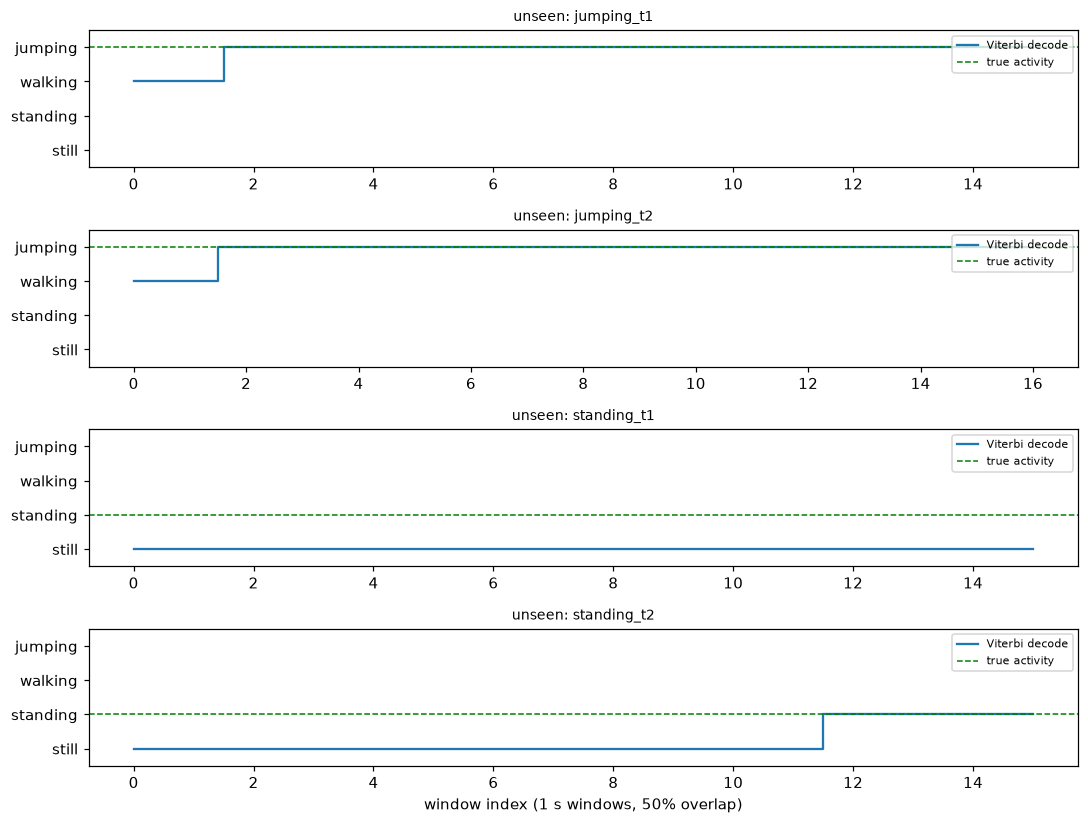

In [11]:
n_show = min(4, len(test_seqs))
fig, axes = plt.subplots(n_show, 1, figsize=(10, 1.9 * n_show), sharex=False)
for ax, path, lab, name in zip(np.atleast_1d(axes), test_paths, test_labels, test_names):
    dec = [state2act[s] for s in path]
    ax.step(range(len(dec)), dec, where='mid', label='Viterbi decode')
    ax.axhline(lab2idx[lab], color='green', ls='--', lw=1, label='true activity')
    ax.set_yticks(range(N_STATES), ACTIVITIES); ax.set_ylim(-0.5, N_STATES - 0.5)
    ax.set_title(f'unseen: {name}', fontsize=9); ax.legend(fontsize=7, loc='upper right')
axes[-1].set_xlabel('window index (1 s windows, 50% overlap)')
plt.tight_layout(); plt.show()

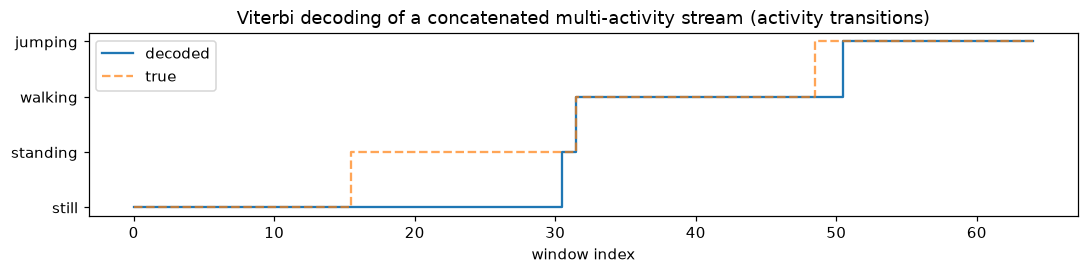

In [12]:
# Bonus: decode one long concatenated multi-activity stream to show transitions
order = ['still', 'standing', 'walking', 'jumping']
chunks, truth = [], []
for act in order:
    s = next((s for s, l in zip(test_seqs, test_labels) if l == act), None)
    if s is not None:
        chunks.append(s); truth += [lab2idx[act]] * len(s)
if chunks:
    stream = np.vstack(chunks)
    dec = [state2act[s] for s in hmm.viterbi(stream)[0]]
    plt.figure(figsize=(10, 2.6))
    plt.step(range(len(dec)), dec, where='mid', label='decoded')
    plt.step(range(len(truth)), truth, where='mid', ls='--', label='true', alpha=0.7)
    plt.yticks(range(N_STATES), ACTIVITIES)
    plt.title('Viterbi decoding of a concatenated multi-activity stream (activity transitions)')
    plt.xlabel('window index'); plt.legend(); plt.tight_layout(); plt.show()

## 7. Optional: cross-check with `hmmlearn`
Not required, but a nice sanity check for the report (`pip install hmmlearn`).

In [13]:
try:
    from hmmlearn.hmm import GaussianHMM as SkGaussianHMM
    lengths = [len(s) for s in train_seqs]
    sk = SkGaussianHMM(n_components=N_STATES, covariance_type='diag',
                       n_iter=200, tol=1e-4, random_state=42)
    sk.fit(np.vstack(train_seqs), lengths)
    print('hmmlearn converged:', sk.monitor_.converged)
    print('hmmlearn transition matrix:\n', np.round(sk.transmat_, 2))
except ImportError:
    print('hmmlearn not installed - skip or `pip install hmmlearn`')

hmmlearn converged: True
hmmlearn transition matrix:
 [[1.   0.   0.   0.  ]
 [0.   0.65 0.35 0.  ]
 [0.   0.44 0.56 0.  ]
 [0.03 0.02 0.   0.95]]


## 8. Analysis and reflection

### Easiest and hardest activities to distinguish

The confusion matrix and the metrics table make the pattern clear. Walking and jumping are the easiest to tell apart, both reaching about 0.97 overall accuracy on the unseen test data. This is because they are the only two activities with strong periodic motion, and the frequency features separate them well: walking has a lower dominant frequency (a slow gait cadence) while jumping shows high spectral energy from the repeated impacts. You can see this in the box plots, where jumping sits far above the others on std_mag, rms_mag, and spectral energy.

The hardest pair is still versus standing. Standing has a sensitivity of only about 0.12, and most standing windows get decoded as still. This makes sense. When you stand and hold the phone at your waist, the phone is almost as motionless as when it lies on a table. Both activities have very low acceleration variance and near zero spectral energy, so their feature vectors overlap heavily. The model is unsupervised, so it has no reason to split two clusters that look almost identical. For the fitness tracker use case this is not a serious problem, because both still and standing count as "rest" and the app mainly needs to separate rest from active movement, which the model does well.

### Are the learned transition probabilities realistic

Mostly yes, with one caveat about how the data was collected. The transition matrix has a very strong diagonal, with self transition probabilities of about 0.92 to 1.0, which means once the model is in an activity it almost always stays there in the next one second window. This matches real behaviour, because people do not switch activities several times per second. The largest off diagonal values connect the two low energy states, still and standing, to each other (about 0.03 and 0.07), which again reflects how similar those two states are. Transitions between a resting state and jumping are essentially zero. The caveat is that each recording contains only a single activity, so the model never saw a real activity change during training. The small off diagonal values therefore come from occasional state confusion inside a single recording, not from genuine activity switches. To learn realistic switching behaviour we would need recordings where the person moves from one activity to the next in one take.

### Effect of sensor noise and sampling rate

All recordings came from one phone, an iPhone 13 mini, with a native rate of about 99.3 Hz. Every file was linearly interpolated onto a common 50 Hz grid so that windows and FFT bins line up. Because only one device was used, there was no real mismatch between sampling rates to correct, but the resampling still matters. Dropping from 100 Hz to 50 Hz sets the highest measurable frequency at 25 Hz, which is more than enough for human motion (walking and jumping are only a few Hz), so no useful information is lost. Sensor noise shows up mainly in the resting states, where tiny vibrations and sensor drift give a small non zero variance. That noise is one reason still and standing are hard to separate, because it partly fills the gap between a truly static signal and a slightly moving one.

### Possible improvements

- Collect more data and from more phones so the model sees different devices and sampling rates.
- Add orientation invariant features, or rely more on the acceleration magnitude, so the result does not depend on how the phone is held.
- Add extra sensors such as the barometer, which could tell standing from still by detecting the small height change when a person stands up.
- Use longer windows to get finer frequency resolution, or initialise the emissions from labelled examples so the model does not merge the two resting states.
- Since still and standing are so similar, another option is to merge them into a single rest state, which fits the fitness tracker goal of separating rest from activity.